# 01 — Mùa vụ & ngày campaign (Chetanic)

**Câu hỏi:** doanh thu tập trung vào thời điểm nào trong năm, và các ngày
campaign lớn của sàn đóng góp thực sự bao nhiêu?

**Phạm vi:** chỉ shop `Chetanic` (loại Lumytive để tránh nhiễu do cơ cấu shop
đổi theo thời gian — Lumytive gần như là shop duy nhất còn hoạt động ở giai
đoạn cuối). Dùng `dim_order_customer` / `fact_order_item_customer` — đã loại
414 đơn vận hành nội bộ (xem `docs/data_quality.md` mục 14). Nếu dùng bảng gốc,
đúng những ngày có campaign sẽ bị đội số đơn giả tạo vì cụm đơn ảo đó được tạo
ra để giữ chỗ flash sale.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.0f}".format

con = duckdb.connect("../data/clean/lazada.duckdb", read_only=True)


In [2]:
orders = con.execute("""
    SELECT
        orderNumber,
        order_date,
        order_created_at,
        strftime(order_date, '%Y-%m')         AS year_month,
        dayofweek(order_date)                 AS weekday_num,   -- 0=CN ... 6=T7 (quy uoc DuckDB)
        strftime(order_created_at, '%A')      AS weekday_name,
        hour(order_created_at)                AS hour,
        payMethod,
        is_completed,
        total_paid_price,
        total_unit_price,
        total_seller_discount,
        total_platform_discount,
        n_items
    FROM dim_order_customer
    WHERE shop = 'Chetanic'
""").df()

orders["order_date"] = pd.to_datetime(orders["order_date"])
print(f"{len(orders):,} don, {orders.order_date.min().date()} -> {orders.order_date.max().date()}")
orders.head(3)


13,168 don, 2020-12-25 -> 2022-11-14


,orderNumber,order_date,order_created_at,year_month,weekday_num,weekday_name,hour,payMethod,is_completed,total_paid_price,total_unit_price,total_seller_discount,total_platform_discount,n_items
0,376955970090883,2022-10-20,2022-10-20 18:21:00,2022-10,4,Thursday,18,COD,True,"77,800","49,000",0,0,1
1,347145615200333,2022-04-15,2022-04-15 13:07:00,2022-04,5,Friday,13,COD,True,"72,154","51,754",0,0,1
2,344810354135247,2022-03-22,2022-03-22 20:07:00,2022-03,2,Tuesday,20,COD,True,"100,900","105,030","14,130",0,3


**Vì sao lấy ở tầng `dim_order_customer` (tầng đơn) chứ không phải
`fact_order_item_customer` (tầng dòng):** câu hỏi mùa vụ ở đây là về *số đơn*,
*AOV*, *tỷ lệ huỷ* — đều là chỉ số tầng đơn. Nếu gộp theo dòng, 1 đơn nhiều
sản phẩm sẽ bị đếm nhiều lần, làm phồng số đơn giả tạo vào đúng những ngày có
đơn nhiều sản phẩm (thường lại là ngày campaign) — sai lệch đúng vào chỗ đang
muốn đo.

**Vì sao dùng `order_created_at` để lấy `weekday`/`hour` thay vì `order_date`:**
`order_date` chỉ có phần ngày (đã `CAST AS DATE` khi dựng `dim_order`), mất
thông tin giờ. `hour` cần cho việc sau này muốn xem giờ vàng trong ngày
campaign (không nằm trong 5 bước đã thống nhất, nhưng để sẵn phòng khi cần).

**Phương án khác:** có thể tính `weekday`/`hour` trực tiếp trong SQL bằng
`dayofweek()`/`hour()` trên `order_created_at` (đã làm) — thay vì kéo hết dữ
liệu thô về rồi dùng `pandas.dt.dayofweek`. Làm trong SQL tận dụng được
DuckDB xử lý song song, nhanh hơn khi dữ liệu lớn hơn (ở đây không đáng kể vì
chỉ 13 nghìn đơn, nhưng là thói quen tốt).

**Chỗ dễ sai:** `dayofweek()` của DuckDB đánh số 0 = Chủ Nhật, 6 = Thứ Bảy —
**khác** với `pandas.Timestamp.weekday()` (0 = Thứ Hai). Nếu sau này trộn cả
2 cách tính trong cùng notebook, "thứ 2" ở chỗ này có thể là "thứ 3" ở chỗ
khác. Đã dùng `weekday_name` (tên chữ, từ `strftime('%A')`) để tránh nhầm khi
đọc bảng — chỉ dùng `weekday_num` khi cần sort theo đúng thứ tự.


## 1. Doanh thu theo tháng — mùa vụ tổng quan

Doanh thu tính theo quy ước đã chốt ở `docs/data_quality.md` mục 15:
`unitPrice - sellerDiscountTotal` (KHÔNG trừ `platformDiscountTotal` vì
Lazada hoàn riêng khoản đó, không làm giảm doanh thu shop thực nhận), và chỉ
tính đơn `is_completed = True` (đơn huỷ không tạo ra doanh thu thật).


C:\Users\Admin\AppData\Local\Temp\ipykernel_8272\4178893654.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(monthly["year_month"], rotation=45, ha="right")


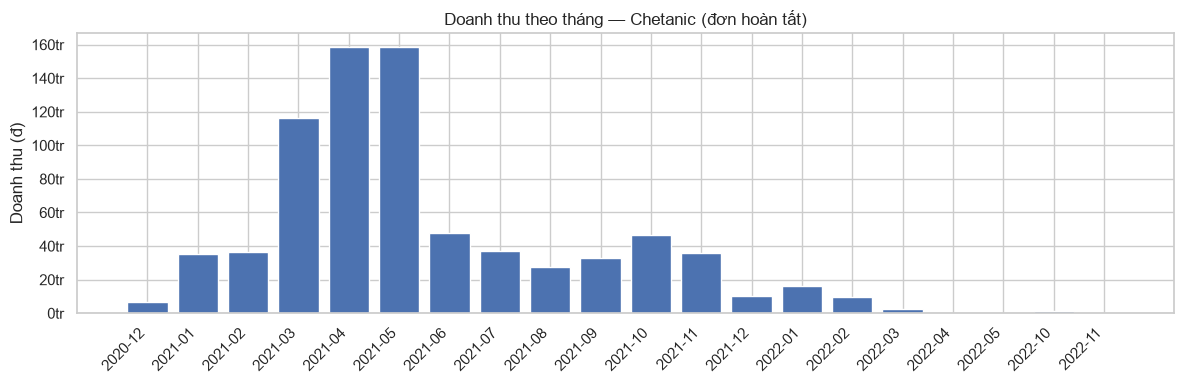

,year_month,doanh_thu,so_don
0,2020-12,"6,935,000",31
1,2021-01,"35,065,268",580
2,2021-02,"36,503,152",565
3,2021-03,"116,565,377",1574
4,2021-04,"158,778,122",1236
5,2021-05,"158,720,410",1202
6,2021-06,"47,707,726",646
7,2021-07,"37,322,033",571
8,2021-08,"27,480,644",386
9,2021-09,"32,582,963",546


In [3]:
orders["net_revenue"] = orders["total_unit_price"] - orders["total_seller_discount"]

monthly = (
    orders.loc[orders.is_completed]
    .groupby("year_month", as_index=False)
    .agg(doanh_thu=("net_revenue", "sum"), so_don=("orderNumber", "count"))
)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(monthly["year_month"], monthly["doanh_thu"], color="#4C72B0")
ax1.set_ylabel("Doanh thu (đ)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f}tr"))
ax1.set_xticklabels(monthly["year_month"], rotation=45, ha="right")
ax1.set_title("Doanh thu theo tháng — Chetanic (đơn hoàn tất)")
plt.tight_layout()
plt.show()

monthly


**Đọc nhanh:** doanh thu không trải đều — đỉnh rõ rệt ở 03/2021–05/2021, tụt
mạnh từ 06/2021, rồi gần như tắt hẳn sau 03/2022 (dữ liệu thưa dần, không hẳn
là "mùa thấp điểm" theo nghĩa mùa vụ — nhiều khả năng là shop giảm hoạt động).
**Chỗ dễ sai:** đừng đọc 04/2022–05/2022 (chỉ 2 đơn/tháng) như một "đáy mùa
vụ" — mẫu quá nhỏ để có ý nghĩa, đó là dấu hiệu ngừng hoạt động chứ không phải
tín hiệu mùa vụ.

## 2. Ngày campaign đôi — đối chiếu giả thuyết với dữ liệu thật

Trước khi so sánh, cần kiểm tra: lịch "ngày đôi" (1.1, 2.2 ... 12.12, 9.9,
11.11) theo quy ước ngành có thật sự khớp với ngày shop chạy flash sale
(`campaign_flag`, tách ở Bước 3) không? Đây là 2 định nghĩa "campaign"
**độc lập** — một bên là lịch mega sale của sàn, một bên là khi chính shop tự
gắn cờ `-FS`. Không mặc nhiên gộp làm một.


In [4]:
import datetime as dt

lo, hi = orders["order_date"].min(), orders["order_date"].max()

double_dates = sorted({
    dt.date(y, m, m)
    for y in range(lo.year, hi.year + 1)
    for m in range(1, 13)
} | {dt.date(y, 9, 9) for y in range(lo.year, hi.year + 1)}
  | {dt.date(y, 11, 11) for y in range(lo.year, hi.year + 1)})
double_dates = [d for d in double_dates if lo.date() <= d <= hi.date()]

fs_rate_baseline = con.execute("""
    SELECT AVG((campaign_flag IS NOT NULL)::INT)
    FROM fact_order_item_customer WHERE shop = 'Chetanic'
""").fetchone()[0]

fs_by_date = con.execute("""
    SELECT order_date, COUNT(*) AS so_dong,
           SUM((campaign_flag IS NOT NULL)::INT) AS so_dong_fs
    FROM fact_order_item_customer
    WHERE shop = 'Chetanic'
    GROUP BY order_date
""").df()
fs_by_date["order_date"] = pd.to_datetime(fs_by_date["order_date"]).dt.date
fs_by_date["ty_le_fs"] = fs_by_date["so_dong_fs"] / fs_by_date["so_dong"]

check = fs_by_date[fs_by_date["order_date"].isin(double_dates)].sort_values("order_date")
check["so_don"] = check["order_date"].map(
    orders.groupby(orders["order_date"].dt.date).size()
)

print(f"Ty le FS trung binh toan bo (baseline): {fs_rate_baseline:.1%}")
check[["order_date", "so_don", "so_dong", "ty_le_fs"]]


Ty le FS trung binh toan bo (baseline): 12.3%


,order_date,so_don,so_dong,ty_le_fs
7,2021-01-01,9,13,0
39,2021-02-02,54,71,0
68,2021-03-03,39,81,0
100,2021-04-04,82,136,0
131,2021-05-05,96,168,0
163,2021-06-06,118,151,0
194,2021-07-07,116,131,1
226,2021-08-08,24,46,0
258,2021-09-09,104,153,0
289,2021-10-10,99,120,0


**Phát hiện ngược với kỳ vọng ban đầu:** trên các ngày mega sale của sàn
(9.9, 10.10, 11.11), tỷ lệ dòng có `campaign_flag = FS` **thấp hơn** mức nền
12,3% (9.9 chỉ 3,9%, 10.10 là 0%, 11.11 chỉ 2,6%) — dù số đơn những ngày này
vẫn cao hơn hẳn ngày thường (11.11 có 194 dòng). Nghĩa là: đơn tăng vào các
ngày này, nhưng **không phải vì shop tự chạy flash sale** — nhiều khả năng là
traffic tự nhiên tăng do sàn quảng bá mega sale toàn nền tảng, còn chiến dịch
`-FS` của riêng shop lại diễn ra vào các ngày khác (vd. 30/12/2021 có tỷ lệ FS
tới 90%, không phải ngày đôi nào cả).

**Ý nghĩa cho phần so sánh tiếp theo:** "ngày campaign" trong bước 4 sẽ dùng
lịch ngày đôi (đúng như đã thống nhất) — nhưng phải hiểu đây là đo **hiệu ứng
traffic từ sàn**, không phải hiệu ứng từ flash sale riêng của shop. Hai câu
hỏi khác nhau, không nên lẫn khi kết luận.


## 3. So sánh gộp nhóm: ngày campaign vs ngày thường

Gộp toàn bộ ngày trong `double_dates` thành 1 nhóm, so với toàn bộ ngày còn
lại — thay vì so từng ngày lẻ (1 ngày = mẫu quá nhỏ, dễ bị nhiễu bởi 1 sự
kiện ngẫu nhiên). Vì số ngày 2 nhóm chênh lệch rất lớn (14 ngày campaign so
với hơn 700 ngày thường), so **tổng** sẽ vô nghĩa — phải quy về **trung bình
mỗi ngày** mới so được.

AOV và tỷ lệ huỷ giữ đúng quy ước đã dùng xuyên suốt project: AOV =
`SUM(paidPrice)` (gồm ship) trung bình trên đơn **hoàn tất**; tỷ lệ huỷ =
mẫu số là **tổng đơn khởi tạo**, không phải đơn hoàn tất.


In [5]:
orders["is_campaign_day"] = orders["order_date"].dt.date.isin(double_dates)

so_ngay = orders.groupby("is_campaign_day")["order_date"].apply(lambda s: s.dt.date.nunique())
tong_don = orders.groupby("is_campaign_day").size()
ty_le_huy = orders.groupby("is_campaign_day")["is_completed"].apply(lambda s: 100 * (1 - s.mean()))

completed = orders[orders.is_completed]
aov = completed.groupby("is_campaign_day")["total_paid_price"].mean()
chiet_khau_tb = completed.groupby("is_campaign_day")[
    ["total_seller_discount", "total_platform_discount"]
].sum().sum(axis=1) / completed.groupby("is_campaign_day").size()

summary = pd.DataFrame({
    "so_ngay": so_ngay,
    "tong_don_khoi_tao": tong_don,
    "don_trung_binh_moi_ngay": (tong_don / so_ngay).round(1),
    "ty_le_huy_pct": ty_le_huy.round(1),
    "AOV_don_hoan_tat": aov.round(0),
    "chiet_khau_tb": chiet_khau_tb.round(0),
})
summary.index = summary.index.map({True: "Ngày campaign", False: "Ngày thường"})
summary


,so_ngay,tong_don_khoi_tao,don_trung_binh_moi_ngay,ty_le_huy_pct,AOV_don_hoan_tat,chiet_khau_tb
is_campaign_day,,,,,,
Ngày thường,435,12248,28,29,"92,411","7,386"
Ngày campaign,14,920,66,26,"75,731","7,960"


In [6]:
# Kiem tra nhieu do thu-trong-tuan: nhom ngay campaign co lech han ve
# cuoi tuan (von da dong don hon binh thuong) khong?
weekday_check = (
    orders[orders.is_campaign_day]
    .drop_duplicates("order_date")["weekday_name"]
    .value_counts()
)
weekday_check


weekday_name
Sunday       5
Thursday     3
Wednesday    3
Tuesday      1
Friday       1
Saturday     1
Name: count, dtype: int64

**Kết quả:** ngày campaign (14 ngày) có **65,7 đơn/ngày**, gấp **2,3 lần**
ngày thường (28,2 đơn/ngày) — đóng góp rõ rệt về sản lượng. Tỷ lệ huỷ thấp
hơn nhẹ (26,4% so với 28,7%). Nhưng **AOV lại thấp hơn** ở ngày campaign
(75.731đ so với 92.411đ, thấp hơn 18%) — trái với kỳ vọng "ngày sale thì mua
nhiều hơn mỗi đơn". Có thể diễn giải: ngày campaign thu hút khách "săn deal"
mua ít món giá rẻ hơn là khách chi tiêu lớn thông thường — cần thận trọng, vì
đây là suy luận, dữ liệu không có giỏ hàng/số sản phẩm dự định mua để xác nhận
trực tiếp.

**Chỗ dễ sai đã cảnh báo trước — kiểm tra lại bằng bảng thứ-trong-tuần:**
5/14 ngày campaign rơi vào Chủ Nhật (35,7%), trong khi một tuần chỉ có 1/7
(14,3%) là Chủ Nhật — nhóm ngày campaign bị lệch hẳn về cuối tuần một cách
ngẫu nhiên (do cách tính ngày đôi trùng lịch). Vì cuối tuần vốn dĩ đã đông đơn
hơn ngày thường bất kể có campaign hay không, **con số "gấp 2,3 lần" ở trên
có thể một phần đến từ hiệu ứng cuối tuần, không thuần là hiệu ứng campaign**.
Notebook này chỉ dừng ở mức nêu ra cảnh báo — muốn tách bạch rõ 2 hiệu ứng
cần kiểm định thống kê có kiểm soát biến (để dành cho `02_flashsale_test.ipynb`).


## 4. Cửa sổ trước Tết — có thật sự "đẩy mạnh" không?

Tết Nguyên Đán 2021 = 12/02/2021, Tết 2022 = 01/02/2022. Cửa sổ trước Tết lấy
14 ngày trước mùng 1 (rộng hơn 10 ngày một chút để không bỏ sót đợt mua sắm
sớm) — **không tính riêng "trong Tết"/"sau Tết"** ở notebook này, chỉ tập
trung câu hỏi "trước Tết có đẩy mạnh không" như đã thống nhất.


In [7]:
tet_days = [dt.date(2021, 2, 12), dt.date(2022, 2, 1)]
pre_tet_windows = [
    (d - dt.timedelta(days=14), d - dt.timedelta(days=1)) for d in tet_days
]

def in_pre_tet(d):
    return any(start <= d <= end for start, end in pre_tet_windows)

orders["is_pre_tet"] = orders["order_date"].dt.date.apply(in_pre_tet)

# So sanh voi nen: chi lay ngay KHONG phai campaign va KHONG phai pre-Tet,
# de khong bi hiệu ứng ngày đôi lẫn vào baseline.
baseline_mask = ~orders["is_campaign_day"] & ~orders["is_pre_tet"]

pre_tet_summary = pd.DataFrame({
    "so_ngay": [
        orders.loc[orders.is_pre_tet, "order_date"].dt.date.nunique(),
        orders.loc[baseline_mask, "order_date"].dt.date.nunique(),
    ],
    "don_trung_binh_moi_ngay": [
        orders[orders.is_pre_tet].shape[0] / orders.loc[orders.is_pre_tet, "order_date"].dt.date.nunique(),
        orders[baseline_mask].shape[0] / orders.loc[baseline_mask, "order_date"].dt.date.nunique(),
    ],
}, index=["Trước Tết (14 ngày)", "Ngày thường (nền)"])
pre_tet_summary.round(1)


,so_ngay,don_trung_binh_moi_ngay
Trước Tết (14 ngày),26,26
Ngày thường (nền),410,28


**Phát hiện KHÔNG khớp giả thuyết ban đầu:** cửa sổ trước Tết có **25,5
đơn/ngày**, còn thấp hơn cả nền chung (28,4 đơn/ngày) — không thấy "đẩy mạnh
trước Tết" như kỳ vọng.

**Nhưng khoan kết luận vội — có một nhầm lẫn tiềm ẩn ở chính cách so sánh
này:** cửa sổ trước Tết 2021 rơi vào 29/01–11/02/2021, đúng giai đoạn shop
**mới bắt đầu** (12/2020 chỉ có 31 đơn/tháng). "Nền chung" lại gồm cả giai
đoạn đỉnh 03–05/2021 (hơn 1.200 đơn/tháng). So sánh 1 cửa sổ ở early-stage với
1 nền pha trộn nhiều giai đoạn tăng trưởng khác nhau là **so sánh lệch mức
nền (level), không phải so sánh mùa vụ thật** — kết luận "trước Tết ít hơn"
ở đây nhiều khả năng phản ánh việc shop còn non trẻ, không phải hành vi mùa
vụ. Đây là lý do cần nhìn trực tiếp bằng biểu đồ theo ngày (ô dưới) thay vì
chỉ tin vào 1 con số trung bình gộp.


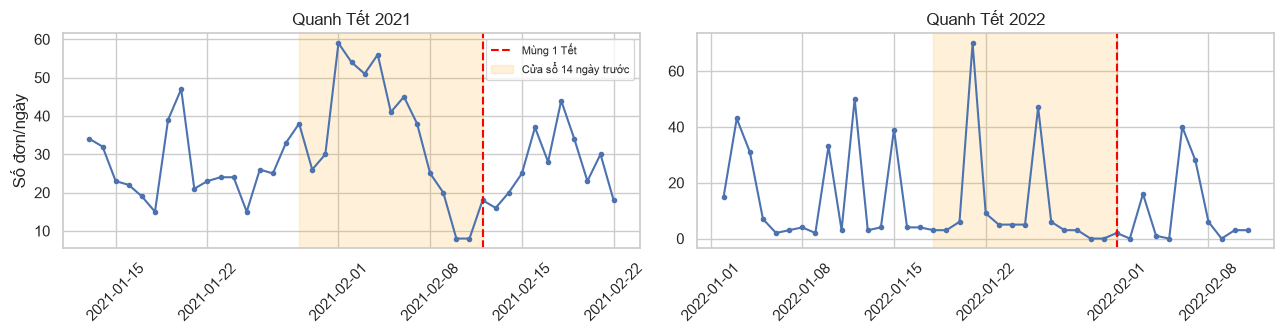

In [8]:
daily = orders.groupby(orders["order_date"].dt.date).size().rename("so_don")
daily.index = pd.to_datetime(daily.index)
daily = daily.asfreq("D", fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=False)
for ax, tet in zip(axes, tet_days):
    tet_ts = pd.Timestamp(tet)
    window = daily.loc[tet_ts - pd.Timedelta(days=30): tet_ts + pd.Timedelta(days=10)]
    ax.plot(window.index, window.values, marker="o", markersize=3)
    ax.axvline(tet_ts, color="red", linestyle="--", label="Mùng 1 Tết")
    ax.axvspan(tet_ts - pd.Timedelta(days=14), tet_ts, color="orange", alpha=0.15, label="Cửa sổ 14 ngày trước")
    ax.set_title(f"Quanh Tết {tet.year}")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Số đơn/ngày")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Nhìn biểu đồ mới thấy rõ điều con số trung bình gộp ở trên đã che mất:**

**Tết 2021** (dữ liệu đủ dày để tin): đơn tăng dần từ ~24–26/ngày (cuối
tháng 1) lên đỉnh **51–59/ngày** đúng vào 01–04/02 (tức 8–11 ngày trước Tết)
— **có đẩy mạnh trước Tết thật**, đúng như giả thuyết ban đầu. Nhưng ngay sau
đỉnh, đơn **rơi tự do** xuống chỉ còn 8/ngày vào 10–11/02 (1–2 ngày ngay
trước Tết), giữ ở mức thấp qua ngày mùng 1, rồi hồi phục dần từ khoảng
15/02.

**Đây chính là lý do bảng trung bình 14 ngày ở trên gây hiểu lầm:** cửa sổ
14 ngày gộp cả pha tăng (ngày 14→3 trước Tết) lẫn pha rơi tự do (ngày 2→1
trước Tết) vào một con số duy nhất, hai pha ngược chiều triệt tiêu lẫn nhau
khi lấy trung bình — ra kết quả "thấp hơn nền" dù thực chất có một đỉnh tăng
rất rõ ở giữa cửa sổ. **Bài học chung: một con số trung bình gộp trên cả cửa
sổ có thể che mất hình dạng thật bên trong — luôn nhìn biểu đồ theo ngày
trước khi tin vào 1 con số tổng hợp.**

**Tết 2022:** dữ liệu quá thưa và nhiễu (nhiều ngày chỉ 3–9 đơn, xen vài đỉnh
39–70 không rõ nguyên nhân) để đọc ra một hình dạng mùa vụ đáng tin — khớp
với nhận xét ở mục 1 rằng shop đã giảm hoạt động mạnh từ đầu 2022. Điểm đáng
tin duy nhất ở năm này: 2 ngày sát Tết (30–31/01) gần như bằng 0 đơn — pha
"ngừng hẳn sát Tết" lặp lại ở cả 2 năm, dù pha tăng trước đó không rõ ràng
bằng 2021.


## 5. Hiện tượng dồn đơn quanh ngày campaign đôi

Rút kinh nghiệm từ mục 4: không lấy 1 số trung bình gộp trước/sau, mà vẽ hẳn
hình dạng theo **ngày lệch so với ngày campaign** (offset), gộp trung bình
qua cả 14 ngày campaign — vừa tránh bẫy "trung bình che hình dạng", vừa đỡ
nhiễu hơn so với chỉ nhìn 1 đợt campaign đơn lẻ.


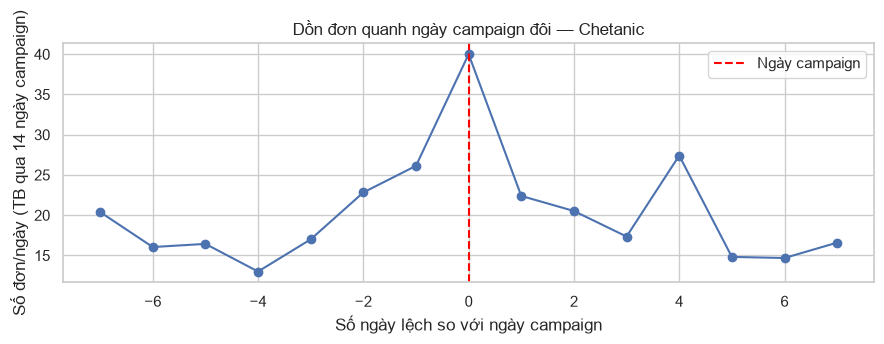

In [9]:
offset_rows = []
for cday in double_dates:
    cday_ts = pd.Timestamp(cday)
    for offset in range(-7, 8):
        d = cday_ts + pd.Timedelta(days=offset)
        so_don = daily.get(d, float("nan"))
        offset_rows.append({"campaign_day": cday, "offset": offset, "so_don": so_don})

offset_df = pd.DataFrame(offset_rows).dropna()
offset_avg = offset_df.groupby("offset")["so_don"].mean()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(offset_avg.index, offset_avg.values, marker="o")
ax.axvline(0, color="red", linestyle="--", label="Ngày campaign")
ax.set_xlabel("Số ngày lệch so với ngày campaign")
ax.set_ylabel("Số đơn/ngày (TB qua 14 ngày campaign)")
ax.set_title("Dồn đơn quanh ngày campaign đôi — Chetanic")
ax.legend()
plt.tight_layout()
plt.show()


**Đọc kết quả:** đơn tăng dần rõ rệt trong 3 ngày ngay trước campaign
(-3: 17,0 → -2: 22,8 → -1: 26,1) lên đỉnh **40,0 đơn/ngày** đúng ngày campaign
(offset 0), rồi giảm ngay lập tức ngày hôm sau (+1: 22,4) và duy trì thấp hơn
đỉnh trong cả tuần sau đó (dao động 14,7–27,4). Xác nhận có "dồn đơn" thật ở
quy mô ngắn (1–3 ngày trước), không chỉ tăng đột ngột đúng ngày campaign rồi
thôi.

Vùng xa hơn (offset -7 đến -4: 13,0–20,4) không cho thấy xu hướng tăng dần rõ
ràng — dao động giống nhiễu ngẫu nhiên hơn là tín hiệu "dồn đơn từ sớm". **Chỗ
dễ sai:** đừng diễn giải quá xa — hiệu ứng dồn đơn ở dữ liệu này chỉ thấy rõ
trong cửa sổ ngắn ±3 ngày quanh campaign, không phải cả tuần.


## Kết luận

- Doanh thu tập trung rõ nhất ở **03–05/2021**, không phải một "mùa" cố định
  theo lịch — trùng giai đoạn shop tăng trưởng mạnh nhất, khó tách bạch với
  yếu tố mùa vụ thuần tuý vì chỉ có ~2 năm dữ liệu (không đủ lặp lại theo năm
  để khẳng định chu kỳ).
- Ngày campaign đôi đóng góp thật về **sản lượng** (gấp 2,3 lần ngày thường)
  nhưng **không** phải nhờ shop tự chạy flash sale (`campaign_flag` thấp hơn
  ngày thường) — traffic tăng có vẻ đến từ chính nền tảng, không phải nỗ lực
  riêng của shop.
- Có "dồn đơn" thật quanh Tết và quanh ngày campaign đôi, nhưng chỉ thấy được
  khi nhìn theo ngày — con số trung bình gộp trên cả cửa sổ dễ che mất hình
  dạng thật (trường hợp Tết 2021 là ví dụ rõ nhất).

## Giới hạn

Chỉ phân tích Chetanic — không tổng quát cho Lumytive hay toàn bộ hoạt động.
Chỉ 2 chu kỳ Tết trong dữ liệu (2021, 2022) — không đủ để khẳng định một mẫu
hình lặp lại hàng năm, có thể là đặc thù của riêng 2 năm này. So sánh ngày
campaign/nhóm ngày thường chưa kiểm soát chặt yếu tố thứ-trong-tuần (chỉ nêu
cảnh báo bằng bảng đếm, chưa kiểm định thống kê) — để dành cho
`02_flashsale_test.ipynb`.
